1. The Residual Plots

The frank model generates synthetic visibilities, which are subtracted from the observed visibilities to produce residual visibilities. These residuals are then imaged using the CLEAN algorithm, resulting in a residual map. Like other radio continuum images, this map has units of flux density per beam (e.g., Jy/beam). To express the residuals in terms of signal-to-noise ratio (SNR), as done in Figure 3 of the exoALMA IV paper, the observed rms noise corresponding to each robust weighting must be extracted from the original image and used to rescale the residual flux densities.

However, since protoplanetary disks are best studied in concentric radial rings from the central star, it's important to consider that the noise level varies with radius. At larger disk radii, more ALMA beams cover each ring, which reduces the azimuthally averaged noise. In contrast, the inner disk tends to show brighter emission but fewer independent beams per bin. Therefore, the azimuthally averaged rms noise within each radial ring provides the most effective way to separate planet-induced substructure signals from noise.

In [1]:
# add autoreload

%load_ext autoreload
%autoreload 2


In [2]:
# import necessary libraries

import os  
import sys
import numpy as np  
import re  # Python’s regular expressions module to extract numbers from filenames
from astropy.io import fits
import pandas as pd
from gofish import imagecube
import matplotlib.pyplot as plt
import glob   # to find files matching a pattern
from reproject import reproject_interp
from IPython.display import display
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import astropy.units as u
 
import pickle # to save and load Python objects

# 
#from disk_residuals_median_SNR import DiskResiduals_Median_SNR as DiskResiduals


sys.path.insert(0, os.path.abspath('.'))

import disk_residuals_median_SNR
import importlib
importlib.reload(disk_residuals_median_SNR)
DiskResiduals = disk_residuals_median_SNR.DiskResiduals_Median_SNR


In [3]:
# load the all_disk object 

### Chapter 1: Compute and Plot the Residual Profiles 

In [4]:

# load the all_disk object  (does not have source_detection yet) 

with open('disk_object_files/all_disks.pkl', 'rb') as f:
    all_disks = pickle.load(f)


In [5]:
def plot_profiles_new(self, robust_val="1.0", FOV=None, radius_unit="arcsec", use_full_fov=False, figsize=(12, 6), all_disks=None ):
        """
        Plot radial profiles for one disk (default) or all disks (if all_disks is provided).
        If all_disks is dict: plot all disks in subplots (3x5), shared y-axis, individual x-axis, no legend.
        """
        import numpy as np
        import matplotlib.pyplot as plt
        from matplotlib.ticker import MaxNLocator , LogLocator
        def _plot_single_disk_profile(disk_obj, ax, robust_val, FOV, radius_unit, use_full_fov):
            r = disk_obj._rkey(robust_val)
            if not disk_obj.has_robust(r):
                ax.set_title(f"{disk_obj.name}\n[Missing robust {r}]")
                ax.axis('off')
                ax.set_yticks([])
                return

            # Load cubes
            if use_full_fov:
                cube_clean = disk_obj.get_cube("2.0", cube_type="clean", use_full_fov=True)
                cube_clean = disk_obj.mask_inner_region(cube_clean, factor=2.0)
                cube_resid = None
            else:
                cube_clean = disk_obj.get_cube(r, FOV=FOV, cube_type="clean")
                cube_resid = disk_obj.get_cube(r, FOV=FOV, cube_type="residual")

            # CLEAN radial profile
            x_cl, y_cl, dy_cl = cube_clean.radial_profile(
                inc=disk_obj.inc, PA=disk_obj.PA, unit='Jy/beam',
                assume_correlated=True, use_mad=True
            )

            # If using full FOV, optionally crop to outer disk region
            if use_full_fov and hasattr(disk_obj, "disksize"):
                r90 = float(disk_obj.disksize.get("R90", 0))
                if r90 > 0:
                    # Convert 2×R90 into the same units as x_cl
                    scale = disk_obj.distance_pc if radius_unit == "au" else 1.0
                    x_min = 2.0 * r90 * scale
                    mask = x_cl >= x_min
                    if np.any(mask):  # only apply if not all False
                        x_cl, y_cl, dy_cl = x_cl[mask], y_cl[mask], dy_cl[mask]
            
            
            
            # Residual radial profile
            if (not use_full_fov) and (cube_resid is not None):
                x_res, y_res, dy_res = cube_resid.radial_profile(
                    inc=disk_obj.inc, PA=disk_obj.PA, unit='Jy/beam',
                    assume_correlated=True, use_mad=True
                )
            else:
                x_res = y_res = dy_res = None

            # Radius units
            if radius_unit == "au":
                x_cl = x_cl * disk_obj.distance_pc
                if x_res is not None:
                    x_res = x_res * disk_obj.distance_pc
                xlabel = "Radius (au)"
                gap_unit_factor = disk_obj.distance_pc
            else:
                xlabel = "Radius (arcsec)"
                gap_unit_factor = 1.0

            if (not use_full_fov):
                if hasattr(disk_obj, "disksize"):
                    R90 = disk_obj.disksize["R90"] * gap_unit_factor
                    err_low = disk_obj.disksize.get("R90_err_low", 0.0) * gap_unit_factor
                    err_high = disk_obj.disksize.get("R90_err_high", 0.0) * gap_unit_factor
                    ax.axvline(R90, color='k', linestyle='--')
                    if (err_low > 0) or (err_high > 0):
                        ax.axvspan(R90 - err_low, R90 + err_high, color='k', alpha=0.15)
                    
                    ax.text(
                        0.95, 0.95,
                        f"$R_{{90}} = {R90:.2f}$ {radius_unit}",
                        transform=ax.transAxes,
                        ha='right', va='top',
                        fontsize=12, color='k',
                        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')
                    )
            # Plot
            if use_full_fov:
                ax.plot(x_cl, y_cl, color='gray', linewidth=2)
                ax.plot(x_cl, dy_cl, color='crimson', linewidth=2)
                print(f"dy_res min: {dy_res.min()}, max: {dy_res.max()}")
                
            else:
                ax.plot(x_cl, y_cl, color='gray', alpha = 0.3, linewidth=2)
                # ax.errorbar(x_cl, y_cl, dy_cl, fmt='none', ecolor='gray', alpha=0.5, capsize=2)
                if x_res is not None:
                    ax.plot(x_res, dy_res, color='crimson', linewidth=2)
                
            
            ax.set_yscale('log')
            #ax.yaxis.set_major_locator(MaxNLocator(nbins=6))  # Set max 4 major ticks
            #ax.set_ylabel('Intensity (Jy/beam)')
            ax.yaxis.set_major_locator(LogLocator(base=10, numticks=4))
            ax.yaxis.set_minor_locator(plt.NullLocator())
            ax.set_title(disk_obj.name.replace("_", " "))


        
        # --- Main logic ---
        if all_disks is None:
            fig, ax = plt.subplots(constrained_layout=True, figsize=figsize)
            _plot_single_disk_profile(self, ax, robust_val, FOV, radius_unit, use_full_fov)
            ax.set_xlabel("Radius (au)" if radius_unit == "au" else "Radius (arcsec)")
            ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
            plt.show()
        else:
            disk_names = list(all_disks.keys())
            n_disks = len(disk_names)
            ncols = 3
            nrows = 5
            fig, axes = plt.subplots(nrows, ncols, figsize=(12, 15), sharey=True)
            axes = axes.flatten()
            for i, disk_name in enumerate(disk_names):
                disk_obj = all_disks[disk_name]
                _plot_single_disk_profile(disk_obj, axes[i], robust_val, FOV, radius_unit, use_full_fov)
                # Only set x-label for bottom row
                if i == ncols * nrows - ncols:  # bottom left index
                    axes[i].set_xlabel("Radius (au)" if radius_unit == "au" else "Radius (arcsec)")
                    axes[i].set_ylabel("Intensity (Jy/beam)")
            for ax in axes[n_disks:]:
                ax.axis('off')
            plt.tight_layout()
            plt.show()

	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
	 Reverting to standard azimuthal aver

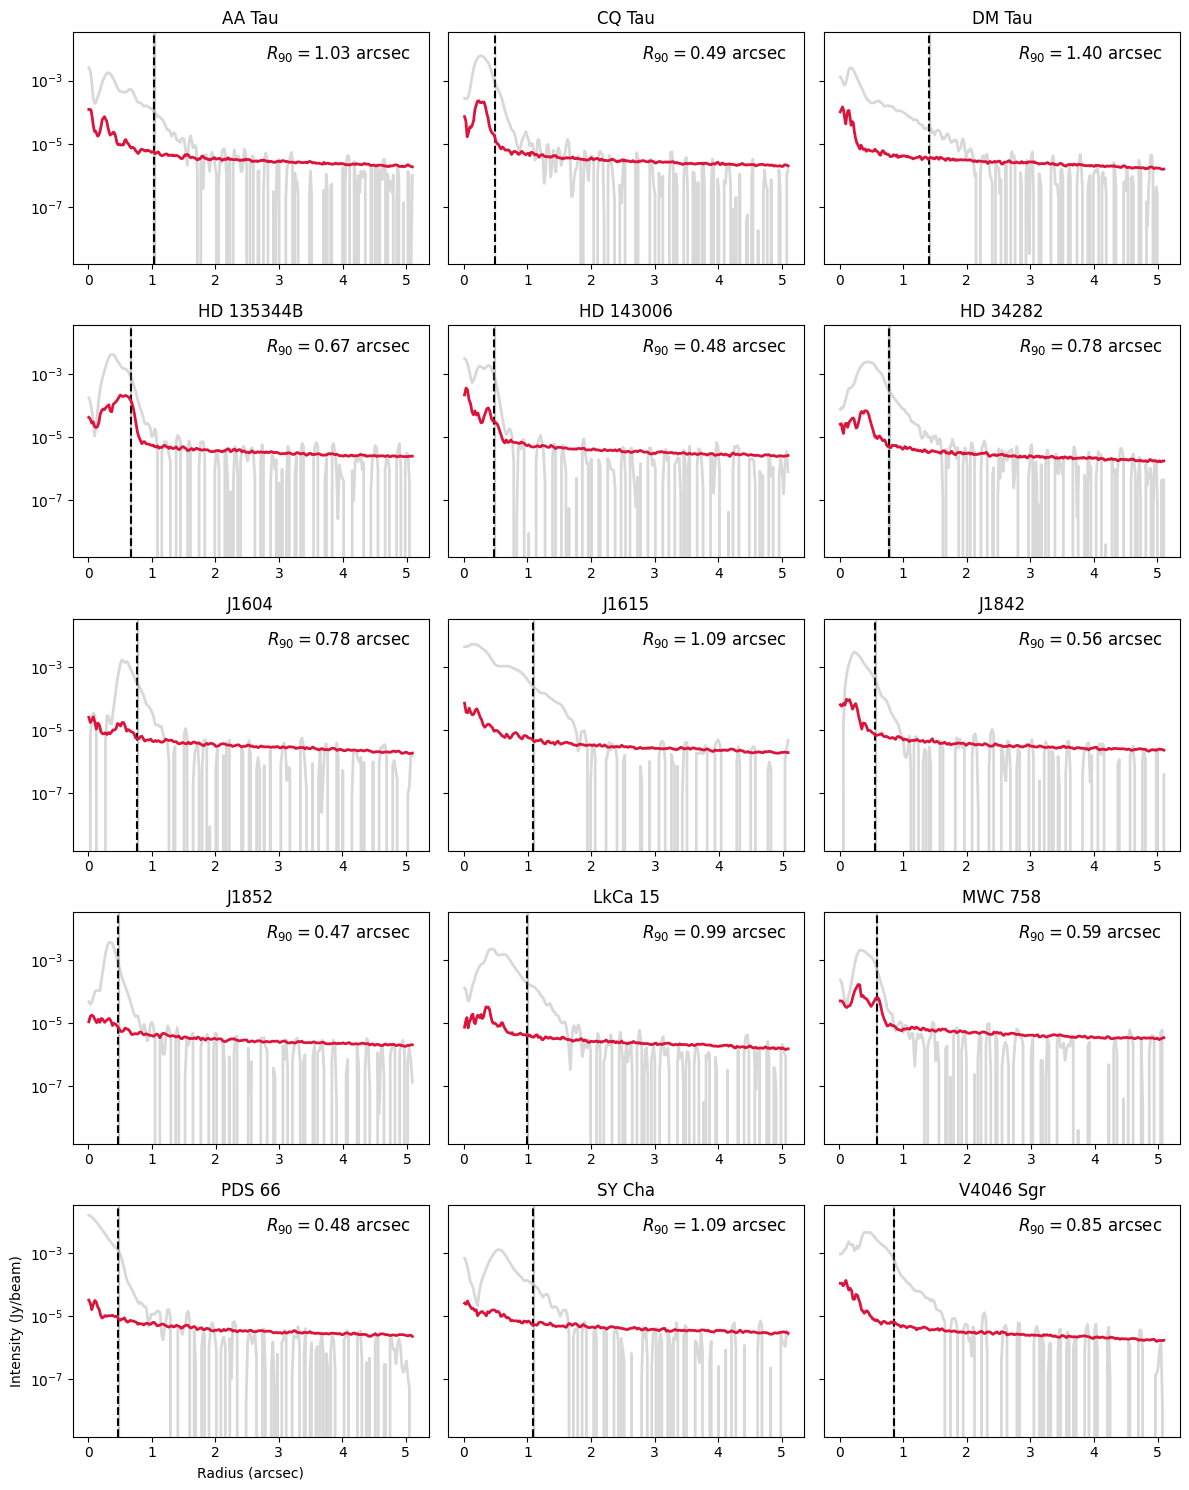

In [6]:

plot_profiles_new(None, robust_val="-0.5", FOV=None, radius_unit="arcsec", use_full_fov=False, figsize=(12, 6), all_disks=all_disks)

### Chapter 2: Gaps

The origin of the gaps: how are they discovered. And the 

In [7]:
def plot_inner_profiles_with_gaps(all_disks, robust_val="1.0", radius_unit="au", figsize=(12, 15)):
    import matplotlib.pyplot as plt
    import numpy as np

    # Manuscript-style formatting
    plt.rcParams.update({
        "font.size": 8,
        "axes.linewidth": 0.8,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "axes.titlesize": 9,
    })

    disk_names = list(all_disks.keys())
    n_disks = len(disk_names)
    ncols = 3
    nrows = 5
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, sharey=True)
    axes = axes.flatten()

    for i, disk_name in enumerate(disk_names):
        disk_obj = all_disks[disk_name]
        ax = axes[i]

        # Load CLEAN radial profile
        rkey = disk_obj._rkey(robust_val)
        cube_clean = disk_obj.get_cube(rkey, cube_type="clean")
        x_cl, y_cl, dy_cl = cube_clean.radial_profile(
            inc=disk_obj.inc, PA=disk_obj.PA, unit='Jy/beam',
            assume_correlated=True, use_mad=True
        )

        # Mask beyond R90
        if hasattr(disk_obj, "disksize"):
            R90 = disk_obj.disksize["R90"] * (disk_obj.distance_pc if radius_unit == "au" else 1.0)
            mask = (x_cl * (disk_obj.distance_pc if radius_unit == "au" else 1.0)) <= R90
            x_cl = x_cl[mask]
            y_cl = y_cl[mask]

        # Convert radius
        if radius_unit == "au":
            x_cl = x_cl * disk_obj.distance_pc
            xlabel = "Radius (au)"
        else:
            xlabel = "Radius (arcsec)"

        # Plot CLEAN profile
        ax.plot(x_cl, y_cl, color="grey", linewidth=1.5, alpha=0.8)

        # -------------------------
        # Gap / Ring annotation
        # -------------------------
        if hasattr(disk_obj, "ringgap") and disk_obj.ringgap is not None and disk_obj.ringgap.size > 0:
            rg = disk_obj.ringgap
            if rg.ndim == 1:
                rg = rg[np.newaxis, :]

            # Get axis limits
            xmin, xmax = ax.get_xlim()
            ymin, ymax = ax.get_ylim()

            # Three tiers, close to the curve, clean
            tiers = [
                ymin + 0.70*(ymax - ymin),
                ymin + 0.60*(ymax - ymin),
                ymin + 0.50*(ymax - ymin),
            ]

            # Minimum horizontal spacing between labels
            min_dx = 0.05 * (xmax - xmin)   # 5% axis width

            # Sort by increasing radius
            rg_sorted = rg[np.argsort(rg[:, 0 if radius_unit=="au" else 1])]

            # Keep track of last label position in each tier
            last_x = [-1e9, -1e9, -1e9]

            for row in rg_sorted:

                # Radius + width
                if radius_unit == "au":
                    rad  = row[0]
                    width = None if np.isnan(row[3]) else row[3]
                else:
                    rad  = row[1]
                    width = None if np.isnan(row[4]) else row[4]

                flag = int(row[2])
                prefix = "B" if flag == 1 else "D"

                # Colors
                linecolor = "#4d794d" if flag == 1 else "#6b5b95"
                spancolor = linecolor + "44"

                # Span
                if width is not None and width > 0:
                    ax.axvspan(rad - width/2, rad + width/2, color=spancolor, lw=0)

                # Vertical line
                ax.axvline(rad, color=linecolor, linestyle=":", linewidth=1.1)

                # Pick the FIRST tier where the x separation is large enough
                for k in range(3):
                    if rad - last_x[k] >= min_dx:
                        tier_y = tiers[k]
                        last_x[k] = rad
                        break
                else:
                    # If all tiers are too close, force last tier
                    tier_y = tiers[-1]

                # Slight x offset
                xoff = 0.01 * (xmax - xmin)
                label_x = rad + xoff

                if label_x > xmax * 0.97:
                    ha = "right"
                    label_x = rad - xoff
                else:
                    ha = "left"

                # Clean rotated label
                ax.text(
                    label_x, tier_y,
                    f"{prefix}-{int(rad)}",
                    rotation=28,
                    ha=ha, va="center",
                    fontsize=9,
                    color=linecolor,
                    alpha=0.85
                )

        # Title
        ax.set_title(disk_obj.name.replace("_", " "))

        # Bottom-left labels only
        row = i // ncols
        col = i % ncols
        if row == nrows - 1 and col == 0:
            ax.set_xlabel(xlabel, fontsize=12)
            ax.set_ylabel("Intensity (Jy/beam)", fontsize=12)
        else:
            ax.set_xlabel("")
            ax.set_ylabel("")

        #ax.set_xlim(np.min(x_cl), np.max(x_cl))
        ax.set_yscale("log")
        ax.yaxis.set_major_locator(plt.LogLocator(base=10, numticks=4))
        ax.yaxis.set_minor_locator(plt.NullLocator())

    # Hide unused axes
    for ax in axes[n_disks:]:
        ax.axis("off")

    plt.subplots_adjust(hspace=0.35, wspace=0.25)
    plt.show()


	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
	 Reverting to standard azimuthal averaging; will ignore `unit` argument.
	 Reverting to standard azimuthal aver

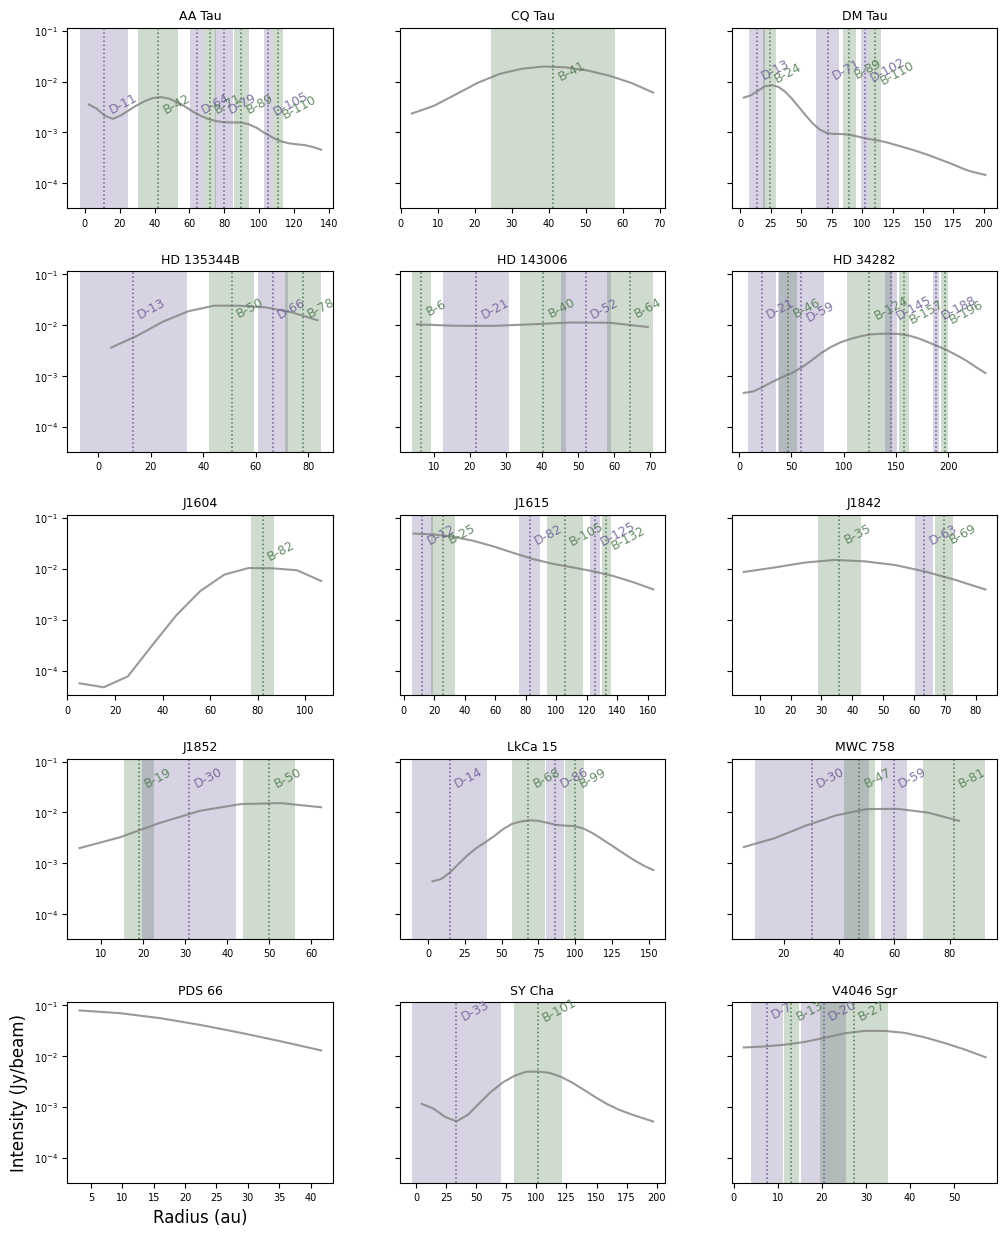

In [8]:
plot_inner_profiles_with_gaps(all_disks, robust_val="2.0", radius_unit="au", figsize=(12, 15))

### Chapter 3. Data...Model...Residual...

In [9]:
# Load everything as fits if possible   , easier to manipulate 
# data, SNR model , SNR plot
# a zzomed in plot for the sources 
# SNR_FITS in D:\CPD_MPIA\Median_SNR\SNR_FITS_Maps\AA_Tau_SNR_robust2.0.fits
# Noise Fits in D:\CPD_MPIA\Median_SNR\Disk_Residual_Profile_Median_SNR\AA_Tau\AA_Tau_sigma_mask_robust2.0.fits 
# original resiudal fits in exoALMA data    D:\exoALMA_disk_data\AA_Tau\images_frank_residuals_different_robust/AA_Tau_continuum_resid_robust2.0.image.fits

# Load fits

import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

disk_names = list(all_disks.keys())

data_dir = "D:/exoALMA_disk_data"
model_dir = "D:/CPD_MPIA/Median_SNR/Disk_Residual_Profile_Median_SNR"
snr_dir = "D:/CPD_MPIA/Median_SNR/SNR_FITS_Maps"

def get_fits_path(disk, kind):
    if kind == "Residual":
        return os.path.join(data_dir, disk, "images_frank_residuals_different_robust", f"{disk}_continuum_resid_robust2.0.image.fits")
    elif kind == "Noise":
        return os.path.join(model_dir, disk, f"{disk}_sigma_mask_robust2.0.fits") # adjust filename as needed
    elif kind == "SNR":
        return os.path.join(snr_dir, f"{disk}_SNR_robust2.0.fits")
    else:
        raise ValueError("Unknown kind")

from astropy.wcs import WCS
from matplotlib.patches import Ellipse

In [10]:
for kind in ["Residual", "Noise", "SNR"]:
        hdr = fits.getheader(get_fits_path("AA_Tau", kind))
        print("\n====", kind, "====")
        print("NAXIS1 =", hdr.get("NAXIS1"))
        print("NAXIS2 =", hdr.get("NAXIS2"))
        print("CDELT1 =", hdr.get("CDELT1"))
        print("CDELT2 =", hdr.get("CDELT2"))
        print("CRPIX1 =", hdr.get("CRPIX1"))
        print("CRPIX2 =", hdr.get("CRPIX2"))


==== Residual ====
NAXIS1 = 1024
NAXIS2 = 1024
CDELT1 = -2.777777777778e-06
CDELT2 = 2.777777777778e-06
CRPIX1 = 513.0
CRPIX2 = 513.0

==== Noise ====
NAXIS1 = 1024
NAXIS2 = 1024
CDELT1 = -2.777777777778e-06
CDELT2 = 2.777777777778e-06
CRPIX1 = 513.0
CRPIX2 = 513.0

==== SNR ====
NAXIS1 = 1024
NAXIS2 = 1024
CDELT1 = -2.777777777778e-06
CDELT2 = 2.777777777778e-06
CRPIX1 = 513.0
CRPIX2 = 513.0


Saved: D:\CPD_MPIA\Images\Res_noi_SNR\AA_Tau.png


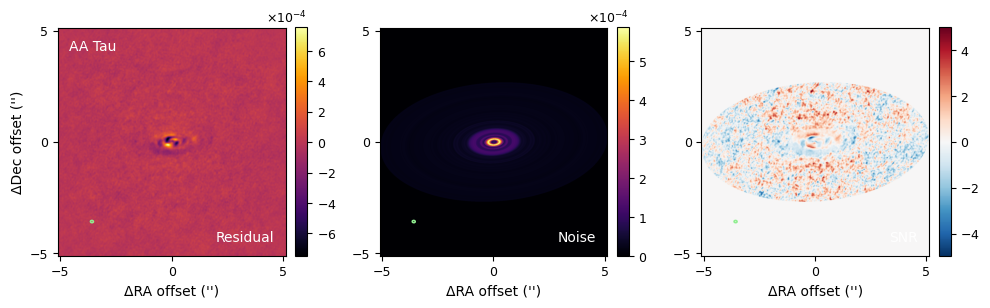

Saved: D:\CPD_MPIA\Images\Res_noi_SNR\CQ_Tau.png


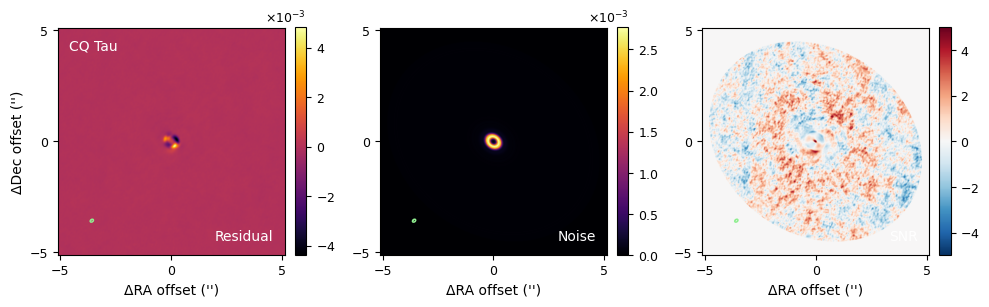

Saved: D:\CPD_MPIA\Images\Res_noi_SNR\DM_Tau.png


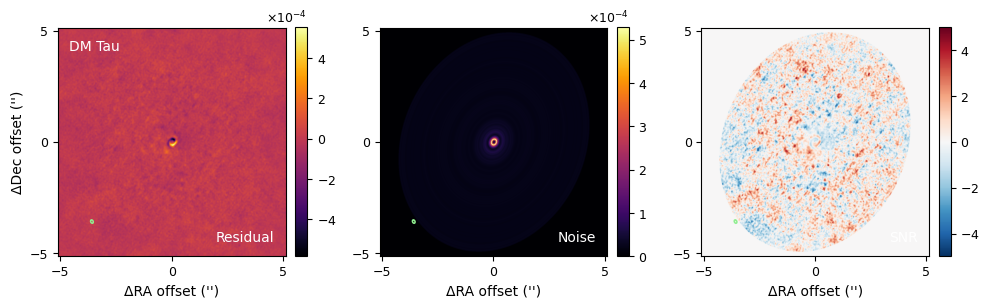

Saved: D:\CPD_MPIA\Images\Res_noi_SNR\HD_135344B.png


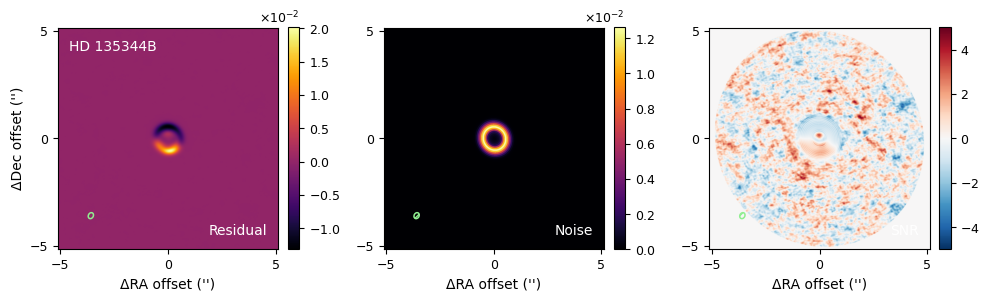

Saved: D:\CPD_MPIA\Images\Res_noi_SNR\HD_143006.png


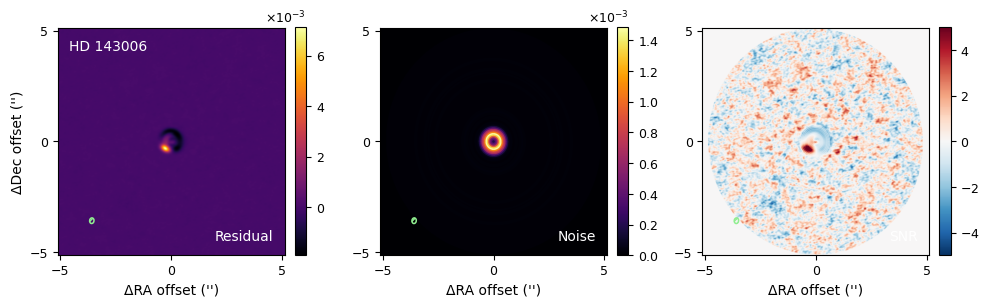

Saved: D:\CPD_MPIA\Images\Res_noi_SNR\HD_34282.png


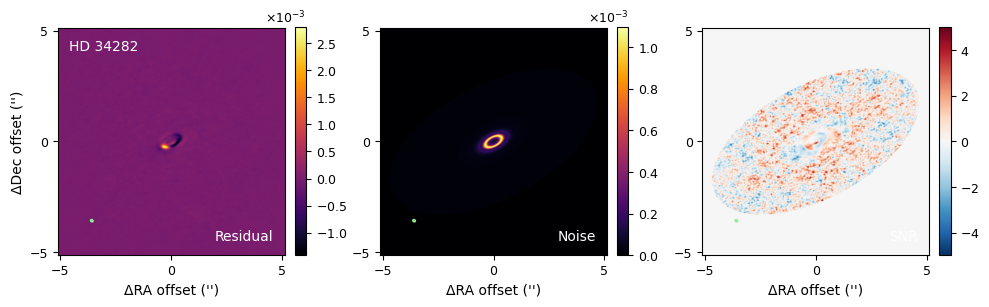

Saved: D:\CPD_MPIA\Images\Res_noi_SNR\J1604.png


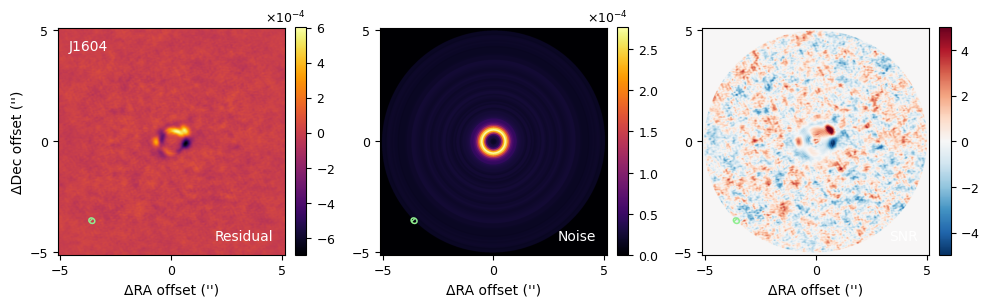

Saved: D:\CPD_MPIA\Images\Res_noi_SNR\J1615.png


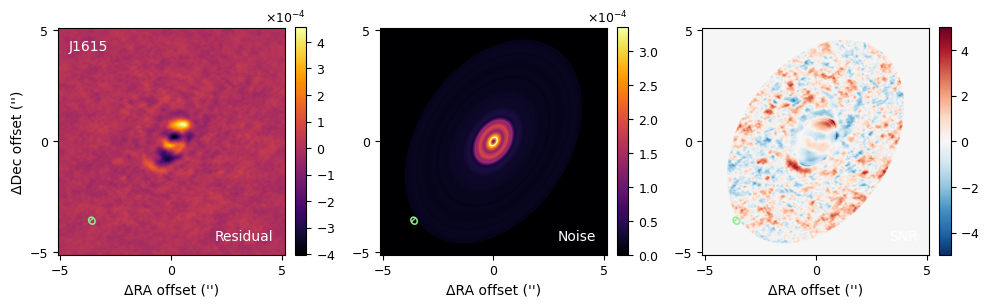

Saved: D:\CPD_MPIA\Images\Res_noi_SNR\J1842.png


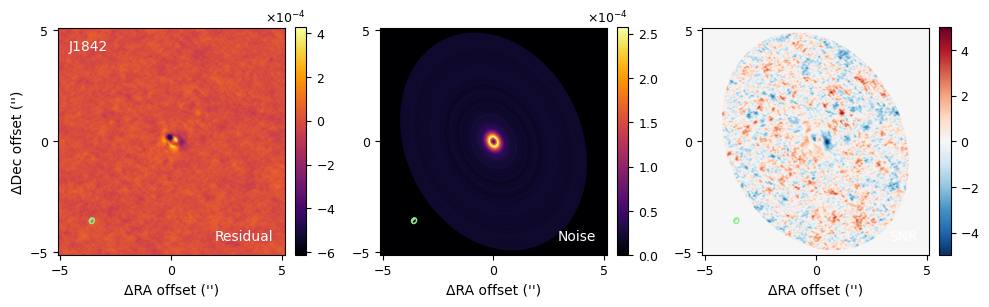

Saved: D:\CPD_MPIA\Images\Res_noi_SNR\J1852.png


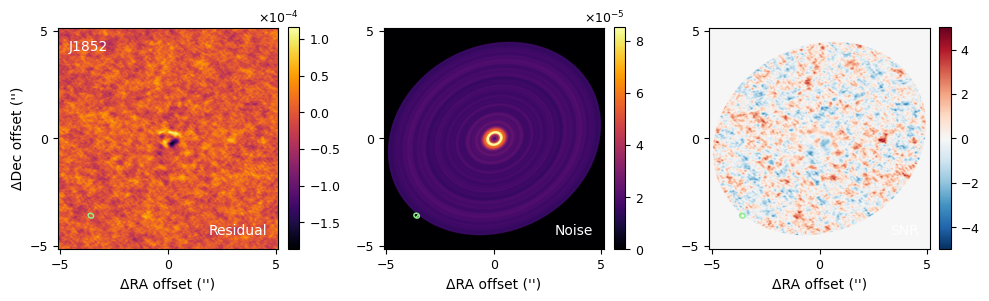

Saved: D:\CPD_MPIA\Images\Res_noi_SNR\LkCa_15.png


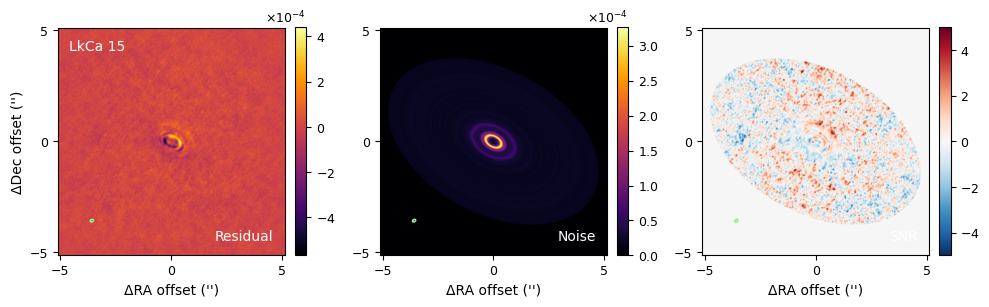

Saved: D:\CPD_MPIA\Images\Res_noi_SNR\MWC_758.png


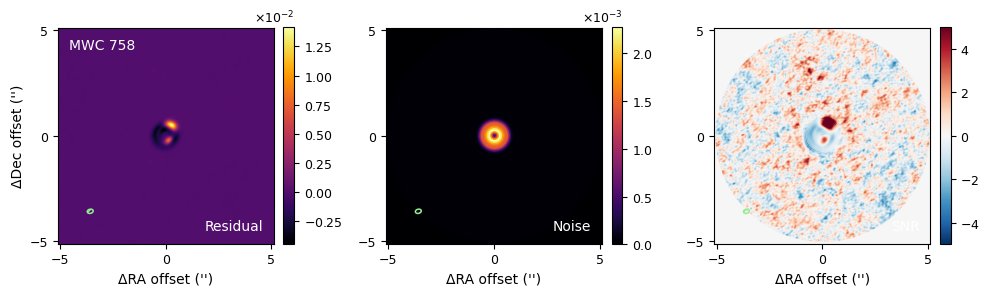

Saved: D:\CPD_MPIA\Images\Res_noi_SNR\PDS_66.png


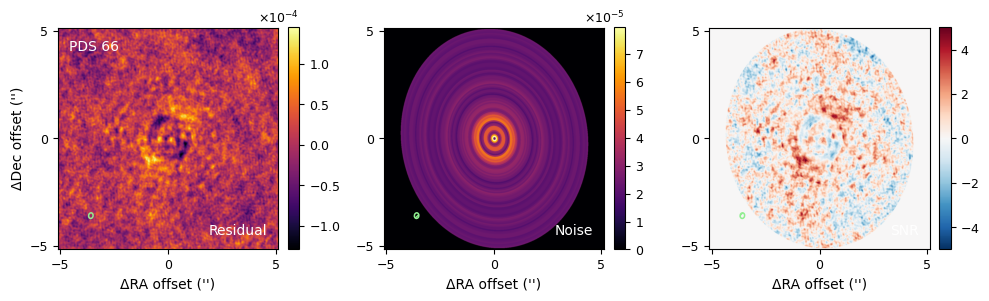

Saved: D:\CPD_MPIA\Images\Res_noi_SNR\SY_Cha.png


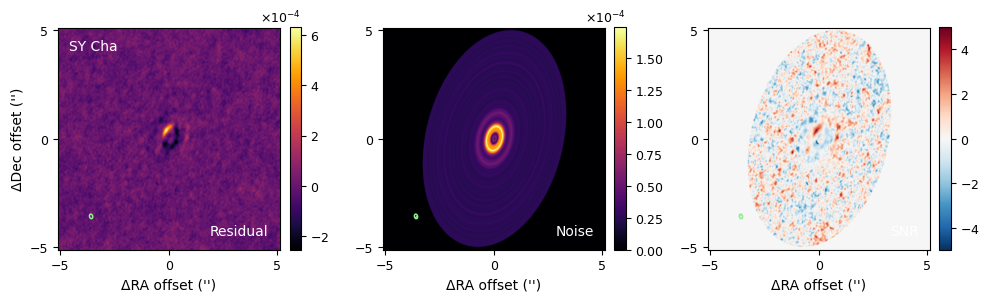

Saved: D:\CPD_MPIA\Images\Res_noi_SNR\V4046_Sgr.png


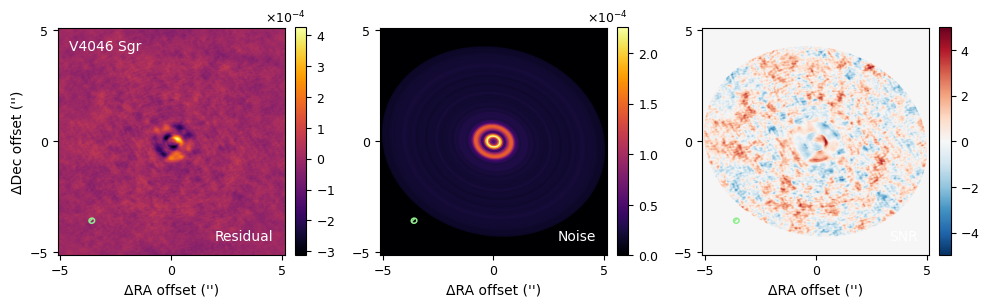

In [11]:
# Load everything as fits if possible   , easier to manipulate 
# data, SNR model , SNR plot
# a zzomed in plot for the sources 
# SNR_FITS in D:\CPD_MPIA\Median_SNR\SNR_FITS_Maps\AA_Tau_SNR_robust2.0.fits
# Noise Fits in D:\CPD_MPIA\Median_SNR\Disk_Residual_Profile_Median_SNR\AA_Tau\AA_Tau_sigma_mask_robust2.0.fits 
# original resiudal fits in exoALMA data    D:\exoALMA_disk_data\AA_Tau\images_frank_residuals_different_robust/AA_Tau_continuum_resid_robust2.0.image.fits

# Load fits

from matplotlib import rcParams
from matplotlib.ticker import MaxNLocator

# Set global font sizes
rcParams['font.size'] = 10
rcParams['axes.labelsize'] = 10
rcParams['xtick.labelsize'] = 9
rcParams['ytick.labelsize'] = 9
rcParams['legend.fontsize'] = 9
rcParams['axes.titlesize'] = 12

for disk in disk_names:
    fig, axes = plt.subplots(1, 3, figsize=(10, 4), squeeze=False)
    
    # Get reference header from Residual for coordinate system
    ref_fits_path = get_fits_path(disk, "Residual")
    ref_hdr = fits.getheader(ref_fits_path)
    
    # Compute reference extent once
    if "CDELT1" in ref_hdr:
        ref_pix_scale = abs(ref_hdr["CDELT1"]) * 3600.0
    elif "CD1_1" in ref_hdr:
        ref_pix_scale = abs(ref_hdr["CD1_1"]) * 3600.0
    
    ref_x0 = ref_hdr["CRPIX1"] - 1 if "CRPIX1" in ref_hdr else None
    ref_y0 = ref_hdr["CRPIX2"] - 1 if "CRPIX2" in ref_hdr else None
    from astropy.io import fits

    
    for j, kind in enumerate(["Residual", "Noise", "SNR"]):
        ax = axes[0, j]
        fits_path = get_fits_path(disk, kind)
        if os.path.exists(fits_path):
            img = fits.getdata(fits_path)
            hdr = fits.getheader(fits_path)
            
            img = np.squeeze(img)
            if img.ndim > 2:
                img = img[-1, -1, :, :]
            
            ny, nx = img.shape
            
            # For Noise map, use reference coordinate system
            if kind == "Noise":
                pix_scale = ref_pix_scale
                x0 = ref_x0 if ref_x0 is not None else nx / 2.0
                y0 = ref_y0 if ref_y0 is not None else ny / 2.0
            else:
                # Get pixel scale in arcsec/pixel
                if "CDELT1" in hdr:
                    pix_scale = abs(hdr["CDELT1"]) * 3600.0
                elif "CD1_1" in hdr:
                    pix_scale = abs(hdr["CD1_1"]) * 3600.0
                else:
                    raise ValueError("No pixel scale in FITS header")
                
                # Get reference pixel (center)
                if "CRPIX1" in hdr and "CRPIX2" in hdr:
                    x0 = hdr["CRPIX1"] - 1
                    y0 = hdr["CRPIX2"] - 1
                else:
                    x0 = nx / 2.0
                    y0 = ny / 2.0
            
            # Build extent in arcsec coordinates
            extent = [
                -x0 * pix_scale,
                (nx - x0) * pix_scale,
                -y0 * pix_scale,
                (ny - y0) * pix_scale
            ]
            
            # Plot with arcsec coordinates
            if j == 0 or j == 1:
                im = ax.imshow(img, origin='lower', cmap='inferno', extent=extent)
            else:
                im = ax.imshow(img, origin='lower', cmap='RdBu_r', extent=extent )
            
            if j == 2:
                # Set color limits for SNR map
                im.set_clim(vmin=-5, vmax=5)
                cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            else:
                cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
            
            cbar.ax.yaxis.set_major_locator(MaxNLocator(nbins=4))
            cbar.formatter.set_powerlimits((0, 0))  # Forces scientific notation
            cbar.formatter.set_useMathText(True)    # Makes it look like ×10^−3
            cbar.update_ticks()

            
            
            # Add label at lower right
            ax.text(0.95, 0.05, kind,
                    transform=ax.transAxes,
                    ha='right', va='bottom',
                    color='white')
            
            # Add x-axis label to all plots
            ax.set_xlabel("ΔRA offset ('')")
            
            # Only add y-axis label to leftmost plot
            if j == 0:
                ax.set_ylabel("ΔDec offset ('')")
            else:
                ax.set_ylabel("")
            
            ax.set_xticks([-5,0,5])
            ax.set_yticks([-5,0,5])
                
            # --- Beam ellipse ---
            disk_obj = all_disks[disk]
            
            # Use reference header for beam info if Noise map doesn't have it
            beam_hdr = ref_hdr if (kind == "Noise" and "BMAJ" not in hdr) else hdr
            
            if "BMAJ" in beam_hdr and "BMIN" in beam_hdr:
                beam_x_arcsec = float(beam_hdr['BMAJ']) * 3600.0
                beam_y_arcsec = float(beam_hdr['BMIN']) * 3600.0
                
                # Position beam in arcsec coordinates (bottom-left corner)
                beam_x = extent[0] + 0.15 * (extent[1] - extent[0])
                beam_y = extent[2] + 0.15 * (extent[3] - extent[2])
                
                beam = Ellipse(
                    xy=(beam_x, beam_y),
                    width=beam_y_arcsec,
                    height=beam_x_arcsec,
                    angle=-disk_obj.PA,
                    facecolor='none',
                    edgecolor='lightgreen',
                    hatch='///',
                    lw=1.1
                )
                ax.add_patch(beam)   
        
    # Add label inside plot
    axes[0,0].text(0.05, 0.95, disk.replace("_", " "),
                    transform=axes[0,0].transAxes,
                    ha='left', va='top',
                    color='white')
    plt.tight_layout()
    # Save figure
    save_dir = "D:\CPD_MPIA\Images\Res_noi_SNR"
    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, f"{disk}.png")
    plt.savefig(save_path, dpi=300)
    print(f"Saved: {save_path}")
    
    plt.show()
    

### Chapter 4: Zoomed-In of The Sources

- Issue:  beam is too big in zoomed in image and too small in zoomed out image
- hid all the axes label and set them in the big plot

Example way to call  the zhu model

```python
# 2. Compute flux for a fixed Rout/RH (e.g., 0.3)
Flux_vals = np.zeros((len(Mdot_grid), len(Mp_grid)))
for i, Mdot in enumerate(Mdot_grid):
    for j, Mp in enumerate(Mp_grid):

        RHill = rD22 * (Mp / (3 * 1047.56 * HD1423006_disk_arr[1]))**(1/3)
        Rout = 0.3 * RHill

        out = calculate_disk_properties_zhu(
            M_star = HD1423006_disk_arr[1],
            Mp = Mp,
            Mdot = Mdot,
            alpha = 1e-2,
            rp = rD22,
            d_pc = HD1423006_disk_arr[2],
            lam_mm = 1.25,
            Rout = Rout,
            Lstar = HD1423006_disk_arr[3],
        )

        Flux_vals[i, j] = out["F_nu_tot"]

# 3. Plot
plot_zhu_Mp_Mdot_flux(
    Mp_grid, Mdot_grid, Flux_vals,
    disk_arr=HD1423006_disk_arr,
    rp=rD22,
    alpha=1e-2,
    target_flux_arr=HD1423006_target_flux_arr
)

```

In [12]:
# import the model.py files

import sys
import os

# Add the CPD_Emission_Models directory to the Python path
model_dir = r'D:\CPD_MPIA\CPD_Emission_Models'
if model_dir not in sys.path:
    sys.path.append(model_dir)

# Now import the modules
import Zhu_model
import Andrew_model
import Dictionaries
 

In [13]:
import os
for f in os.listdir():
    print(repr(f))

'Disk_Residual_Profile_Median_SNR'
'SNR_FITS_Maps'
'source_detection_outer.txt'
'disk_obj.pkl'
'all_disks.pkl'
'Residual_Plot.ipynb'
'disk_residuals_median_SNR.py'
'__pycache__'
'Plotting.ipynb'
'gaps_summary.pkl'
'all_disk_dicts.pkl'
'Disk_Object.ipynb'
'Residual_Plot copy.ipynb'
'Plot.ipynb'
'Source_Detection.ipynb'
'five_sigma_detections.csv'
'disk_object_files'
'Get_Sigma_At_R.ipynb'
'Andrews'
'Dictionaries.py'
'CPD_summary_plot.pdf'
'CPD_summary_plot.png'


In [14]:
from matplotlib.patches import Circle, Ellipse

def plot_snr_zoom(ax, img, hdr, zoom_arcsec=0.1,
                  disk_centroid=(1000,1000), area=500):

    img = np.squeeze(img)
    ny, nx = img.shape

    # Pixel scale in arcsec
    if "CDELT1" in hdr:
        pix_scale = abs(hdr["CDELT1"]) * 3600.0
    elif "CD1_1" in hdr:
        pix_scale = abs(hdr["CD1_1"]) * 3600.0

    # Centre
    x0, y0 = disk_centroid

    # Zoom in pixels
    zoom_pix = int(zoom_arcsec / pix_scale)

    x1, x2 = max(0, x0 - zoom_pix), min(nx, x0 + zoom_pix)
    y1, y2 = max(0, y0 - zoom_pix), min(ny, y0 + zoom_pix)

    sub = img[y1:y2, x1:x2]

    # -------- EXTENT IN ARCSEC instead of pixels ----------
    extent = [
        (x1 - x0) * pix_scale,
        (x2 - x0) * pix_scale,
        (y1 - y0) * pix_scale,
        (y2 - y0) * pix_scale
    ]

    im = ax.imshow(sub, origin='lower', cmap='RdBu_r', extent=extent)

    # Circle (area in pixels → convert to arcsec)
    pix_radii = np.sqrt(area / np.pi)
    arcsec_radii = pix_radii * pix_scale

    center_circle = Circle((0, 0), radius=arcsec_radii,
                           facecolor='none', edgecolor='black',
                           linestyle='--', linewidth=1.2)
    ax.add_patch(center_circle)

    # ---- Beam ellipse in arcsec ----
    if "BMAJ" in hdr and "BMIN" in hdr:
        bmaj_arc = hdr["BMAJ"] * 3600.0
        bmin_arc = hdr["BMIN"] * 3600.0
        bpa      = hdr.get("BPA", 0.0)

        # place in bottom-left corner
        beam_x = extent[0] + 0.15 * (extent[1]-extent[0])
        beam_y = extent[2] + 0.15 * (extent[3]-extent[2])

        beam = Ellipse((beam_x, beam_y),
                       width=bmin_arc, height=bmaj_arc,
                       angle=-disk_obj.PA,
                       facecolor='none', edgecolor='green',hatch='///', alpha=1.0, lw = 1.2)
        ax.add_patch(beam)


    ax.set_xticks([-zoom_arcsec, 0, zoom_arcsec])
    ax.set_yticks([-zoom_arcsec, 0, zoom_arcsec])
    ax.set_xlabel("ΔRA offset ('')", fontsize=rcParams['font.size'])
    ax.set_ylabel("ΔDec offset ('')", fontsize=rcParams['font.size'])
    ax.tick_params(labelsize=rcParams['font.size']*0.9)

    return im


In [74]:



def plot_snr_full_fov(ax, img, hdr,
                      disk_centroid=(1000, 1000), 
                      ):
    """
    Plot full-SNR map with axes in arcsec offsets,
    centred at disk centroid, with beam and circle.
    """

    img = np.squeeze(img)
    ny, nx = img.shape

    # pixel scale in arcsec / pixel
    if "CDELT1" in hdr:
        pix_scale = abs(hdr["CDELT1"]) * 3600.0
    elif "CD1_1" in hdr:
        pix_scale = abs(hdr["CD1_1"]) * 3600.0
    else:
        raise ValueError("No pixel scale in FITS header")

    if "CRPIX1" in hdr and "CRPIX2" in hdr:
        x0 = int(hdr["CRPIX1"])
        y0 = int(hdr["CRPIX2"])
    else:
        # fallback to image center
        ny, nx = img.shape
        x0 = nx // 2
        y0 = ny // 2

    x_cen, y_cen = disk_centroid
    # ---- Build RA/Dec offset grids (arcsec) ----
    ypix, xpix = np.indices((ny, nx))
    dx = (xpix - x0) * pix_scale
    dy = (ypix - y0) * pix_scale

    # ---- Plot full FOV in arcsec coordinates ----
    # extent = [xmin, xmax, ymin, ymax]
    extent = [dx.min(), dx.max(), dy.min(), dy.max()]

    # color scaling symmetric around 0
    vmax = np.nanmax(np.abs(img))
    im = ax.imshow(img, origin='lower', cmap='RdBu_r',
                   vmin=-vmax, vmax=vmax,
                   extent=extent)

    # magenta cross to denote the centroid
    ax.plot((x_cen - x0) * pix_scale, (y_cen - y0) * pix_scale, marker='+', color='magenta', markersize=12, mew=2)

    # ---- Beam ellipse in arcsec ----
    if "BMAJ" in hdr and "BMIN" in hdr:
        bmaj_arc = hdr["BMAJ"] * 3600.0
        bmin_arc = hdr["BMIN"] * 3600.0
        bpa      = hdr.get("BPA", 0.0)

        # place in bottom-left corner
        beam_x = extent[0] + 0.15 * (extent[1]-extent[0])
        beam_y = extent[2] + 0.15 * (extent[3]-extent[2])

        beam = Ellipse((beam_x, beam_y),
                       width=bmin_arc, height=bmaj_arc,
                       angle=bpa,
                       facecolor='white', alpha=0.7)
        ax.add_patch(beam)

    # ---- Axes formatting ----
    ax.set_xticks([-10, 0, 10])
    ax.set_yticks([-10, 0, 10])
    ax.set_xlabel("ΔRA offset ('')", fontsize=rcParams['font.size'])
    ax.set_ylabel("ΔDec offset ('')", fontsize=rcParams['font.size'])
    ax.axhline(0, color='gray', lw=0.5, alpha=0.5)
    ax.axvline(0, color='gray', lw=0.5, alpha=0.5)
    ax.tick_params(labelsize=rcParams['font.size']*0.9)


    return im


In [ ]:
disk_names = [
    'CQ_Tau',
    'CQ_Tau',
    'V4046_Sgr'
]
disk_radii = [
    165.37,   # CQ Tau r=165 au
    932.14,   # CQ Tau r=932 au
    837.63    # V4046 Sgr
]

disk_centroid =[(1435,1343), (1293,1991) , (1570, 2403)]  
disk_area =[470,  480,  764]

y_lim = [(0.05, 0.8), (0.05, 0.8), (0.01, 0.1)]
x_lim = [(0.05, 0.8), (0.05, 0.8), (0.01, 0.1)]

from Dictionaries import disk_arr, five_sigma_sources

# ===============================
    # ROW 3 → normal Zhu colorbar
    # ===============================
    elif row == 3:

        # Create colorbar axis ONLY here
        cax = fig.add_axes([
            pos.x1 + 0.01,
            pos.y0,
            0.015,
            pos.height
        ])

        cb = fig.colorbar(row_mappables[row], cax=cax)
        cb.set_label(r"$\log_{10}(F_\nu\, [\mu{\rm Jy}])$")

    elif row == 4:
        # colorbar for the new Mp vs alpha row
        cax = fig.add_axes([
            pos.x1 + 0.01,
            pos.y0,
            0.015,
            pos.height
        ])
        cb = fig.colorbar(row_mappables[row], cax=cax)
        cb.set_label(r"$\log_{10}(F_\nu\, [\mu{\rm Jy}])$")

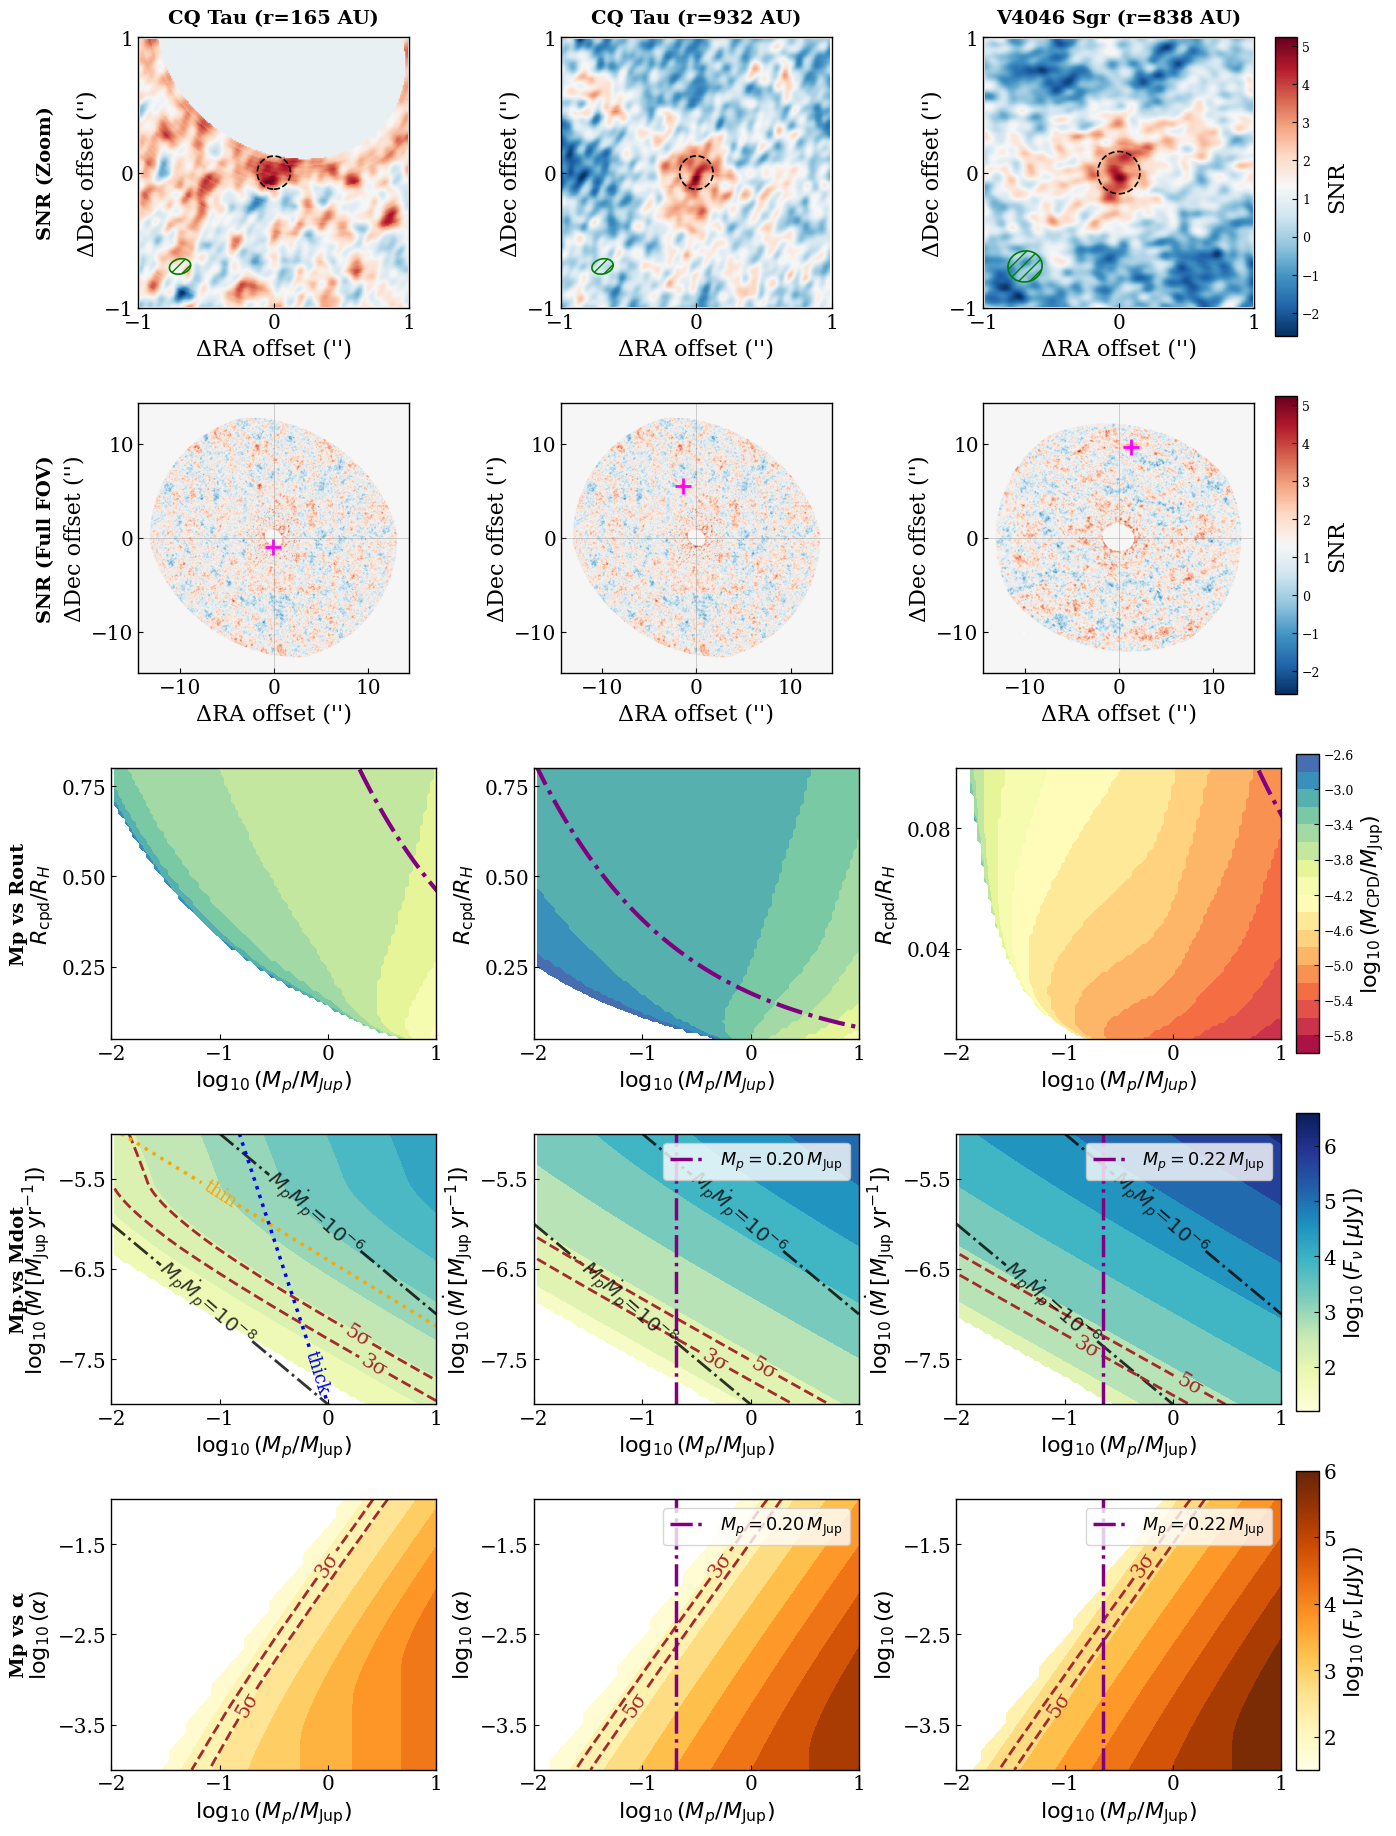

In [106]:
from matplotlib import rcParams
import matplotlib as mpl

# ============================================================
# GLOBAL VISUAL STYLE
# ============================================================
rcParams["font.size"] = 16
rcParams["font.family"] = "serif"
rcParams["axes.linewidth"] = 1.0
rcParams["xtick.direction"] = "in"
rcParams["ytick.direction"] = "in"


fig, axes = plt.subplots(
    5, 3, figsize=(15, 22.5),
    sharex=False, sharey=False,
    gridspec_kw={'height_ratios': [1, 1, 1, 1,1]}   # <-- force all rows equal height
)

# -------------------------------------------------------
# Save ONE mappable per row for the row-level colorbar
# -------------------------------------------------------
row_mappables = [None, None, [], [] ,[]]

for col, (disk_name, disk_radius, centroid, area , ylim) in enumerate(
        zip(disk_names, disk_radii, disk_centroid, disk_area, y_lim)):

    # =====================================================
    # ------------------------- ROW 1 ----------------------
    # =====================================================
    ax = axes[0, col]
    ax.set_aspect('equal', adjustable='box')

    img = fits.getdata(
        f'D:/CPD_MPIA/Median_SNR/SNR_FITS_Maps/{disk_name}_SNR_FullFOV_robust2.0.fits'
    )
    hdr = fits.getheader(
        f'D:/CPD_MPIA/Median_SNR/SNR_FITS_Maps/{disk_name}_SNR_FullFOV_robust2.0.fits'
    )

    im = plot_snr_zoom(ax, img, hdr, 1, centroid, area)

    if col == 2:     # save mappable from last column only
        row_mappables[0] = im


    # =====================================================
    # ------------------------- ROW 2 ----------------------
    # =====================================================
    ax = axes[1, col]
    ax.set_aspect('equal', adjustable='box')

    im = plot_snr_full_fov(ax, img, hdr, centroid)

    if col == 2:
        row_mappables[1] = im

    # =====================================================
    # ------------------------- ROW 3 ----------------------
    # =====================================================
    ax = axes[2, col]
    ax.set_aspect('auto')

    df = pd.read_csv(
        rf'D:\CPD_MPIA\CPD_Emission_Models\Andrews\{disk_name}_{disk_radius}_alpha0.001_5sigma.csv'
    )

    Mp_grid = df['Mp_grid'].unique()
    Rout_frac_grid = df['Rout_frac_grid'].unique()

    Flux_vals = df.pivot(
        index='Rout_frac_grid', columns='Mp_grid', values='Flux_vals'
    ).values

    M_cpd_chosen = df.pivot(
        index='Rout_frac_grid', columns='Mp_grid', values='Mcpd_vals'
    ).values

    im = Andrew_model.plot_flux_map(
         Mp_grid, Rout_frac_grid, Flux_vals, M_cpd_chosen,
         disk_arr=disk_arr[disk_name], ax=ax,
         rp=disk_radius, alpha=1e-3,
         x_min=-2, x_max=1,  
         y_min=ylim[0], y_max=ylim[1],
         min = -6, max = -2.5,
         res_au=disk_arr[disk_name][4] * disk_arr[disk_name][2],
         sigma_ujy=five_sigma_sources[col][3],
         det_sigma=five_sigma_sources[col][5],
    )

    # Save ALL 3 Andrew-model mappables for shared colorbar later
    #if row_mappables[2] is None:
    #    row_mappables[2] = []

    
    row_mappables[2].append(im)



    # =====================================================
    # ------------------------- ROW 4 ----------------------
    # =====================================================
    ax = axes[3, col]
    ax.set_aspect('auto')

    Mp_grid = np.logspace(-2, 1, 100)
    Mdot_grid = np.logspace(-8, -5, 100)

    Flux_vals = np.zeros((len(Mdot_grid), len(Mp_grid)))
    bmaj = disk_arr[disk_name][4] # arcsec

    for i, Mdot in enumerate(Mdot_grid):
        for j, Mp in enumerate(Mp_grid):

            RHill = five_sigma_sources[col][1] * (Mp / (3 * 1047.56 * disk_arr[disk_name][1]))**(1/3)
            Rout = 0.3 * RHill

            out = Zhu_model.calculate_disk_properties_zhu(
                M_star=disk_arr[disk_name][1],
                Mp=Mp,
                Mdot=Mdot,
                alpha=1e-3,
                rp=five_sigma_sources[col][1],
                d_pc=disk_arr[disk_name][2],
                lam_mm=0.9,
                Rout=Rout,
                Lstar=disk_arr[disk_name][3],
            )

            Flux_vals[i, j] = out["F_nu_tot"]

    im = Zhu_model.plot_zhu_Mp_Mdot_flux(
        Mp_grid, Mdot_grid, Flux_vals,
        disk_arr=disk_arr[disk_name],
        rp=disk_radius,
        alpha=1e-4,
        target_flux_arr=[five_sigma_sources[col][3]],
        ax=ax,
        beam_major_arcsec=bmaj,
        plot_thick_thin = True if col == 0 else False
    )

    row_mappables[3].append(im)


    # =====================================================
    # ------------------------- ROW 5 (NEW) ----------------
    # add Mp vs alpha Zhu map as requested
    # =====================================================
    ax = axes[4, col]
    ax.set_aspect('auto')

    # parameters for the new Mp-alpha panel (use example values; adapt if needed)

    rp_local = disk_radius
    Mdot = None       # M_jup/yr (adjust per-column if desired)

    target_flux_arr_local = [five_sigma_sources[col][3]]

    Mp_grid_alpha, alpha_grid, Flux_map = Zhu_model.compute_flux_map_zhu_MpAlpha(
            disk_arr[disk_name],
            Mdot=Mdot,
            rp=rp_local,
            lam_mm=0.9,
            verbose=False
        )

    im = Zhu_model.plot_zhu_Mp_alpha_flux(
            Mp_grid_alpha, alpha_grid, Flux_map,
            disk_arr=disk_arr[disk_name],
            rp=rp_local,
            Mdot=Mdot,
            target_flux_arr=target_flux_arr_local,
            beam_major_arcsec = disk_arr[disk_name][4],  # arcsec
            ax=ax
        )
    row_mappables[4].append(im)



# ===============================================================
# ---------------- ONE COLORBAR PER ROW -------------------------
# ===============================================================

for row in range(5):

    ax_last = axes[row, -1]
    pos = ax_last.get_position()

    # ===============================
    # ROW 0 & 1 
    # ===============================
    if row == 0 or row == 1:

        # Use SNR mappable from Row 0
        snr_mappable = row_mappables[0]

        # Position spans Row 0 + Row 1
        ax0 = axes[0, -1]
        ax1 = axes[1, -1]
        pos0 = ax0.get_position()
        pos1 = ax1.get_position()

        # Create shared vertical colorbar axis
        cax = fig.add_axes([
            pos.x1 + 0.01,
            pos.y0,
            0.015,
            pos.height
        ])

        cb = fig.colorbar(snr_mappable, cax=cax)
        cb.set_label("SNR", fontsize=rcParams["font.size"])

        # Remove left ticks (NO MORE 0–1 scale)
        cb.ax.tick_params(left=False, labelleft=False)

    # ===============================
    # ROW 2 → shared Andrews model bar
    # ===============================
    elif row == 2:

        # Compute shared vmin/vmax
        mapps = row_mappables[2]


        vmin, vmax = -6, -2.5
        norm = plt.Normalize(vmin=vmin, vmax=vmax)

        for m in mapps:
            m.set_norm(norm)

        # Create colorbar axis ONLY here
        cax = fig.add_axes([
            pos.x1 + 0.01,
            pos.y0,
            0.015,
            pos.height
        ])

        cb = fig.colorbar(mapps[0], cax=cax)
        cb.set_label(r"$\log_{10}(M_{\rm CPD}/M_{\rm Jup})$", fontsize=rcParams["font.size"])

    # ===============================
    # ROW 3 → normal Zhu colorbar
    # ===============================
    elif row == 3 or row ==4:
        if row == 3:
            mapps = row_mappables[3]  # list of 3 mappables
        else :
            mapps = row_mappables[4] 

        vmin = min(m.get_clim()[0] for m in mapps if m is not None and hasattr(m, "get_clim"))
        vmax = max(m.get_clim()[1] for m in mapps if m is not None and hasattr(m, "get_clim"))

        norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

        for m in mapps:
            if m is not None and hasattr(m, "set_norm"):
                m.set_norm(norm)

        cmap = mapps[0].cmap if (mapps and mapps[0] is not None and hasattr(mapps[0], "cmap")) else "viridis"
        sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
        sm.set_array([])

        cax = fig.add_axes([pos.x1 + 0.01, pos.y0, 0.015, pos.height])
        cb = fig.colorbar(sm, cax=cax)
        cb.set_label(r"$\log_{10}(F_\nu\, [\mu{\rm Jy}])$", fontsize=rcParams["font.size"])
        cb.ax.tick_params(labelsize=rcParams["font.size"] * 0.9)

   


#          LEFT Y-LABELS FOR EACH ROW (PUBLICATION STYLE)
# ===============================================================

row_side_labels = [
    "SNR (Zoom)", "SNR (Full FOV)",
    "Mp vs Rout",
    "Mp vs Mdot",
    "Mp vs α"
]

for row in range(5):
    axes[row,0].annotate(
            row_side_labels[row],
            xy=(0, 0.5), xycoords='axes fraction',
            xytext=(-60, 0), textcoords='offset points',
            ha='right', va='center',
            rotation='vertical',
            fontsize=14, fontweight='bold'
        )

# ===============================================================
#        ADD OVERALL COLUMN LABELS AT TOP
# ===============================================================
column_titles = ["CQ Tau (r=165 AU)", "CQ Tau (r=932 AU)", "V4046 Sgr (r=838 AU)"]
for col in range(3):
    axes[0, col].set_title(column_titles[col], fontsize=14, pad=10, fontweight='bold')

# ===============================================================
#     ADJUST SPACING FOR LABELS AND COLORBARS
# ===============================================================
plt.subplots_adjust(
    left=0.12,    # restore left margin
    hspace=0.35,
    wspace=0.30
)


plt.show()


Summary of observed properties and modelling constraints for the high–SNR CPD candidates in the ExoELMo survey.
Row 1: Continuum maps showing the spatial extent of the ≥3σ emission (black contours), within which ≥5σ peaks are detected. The beam size is indicated by the green ellipse in the lower-left corner, highlighting that the detected structures are resolved relative to the synthesized beam.
Row 2: SNR maps across the full FOV of each disk. Magenta crosses mark the locations of the ≥5σ detections.
Row 3: Minimum detectable CPD mass predicted from the Andrews et al. (2021) irradiated–disk model. The purple line shows the resolution limit (R_out = 0.5 × beam FWHM). In this model, the accretion rate is fixed to 10⁻⁶ M* yr⁻¹, and the CPD flux is independent of the viscosity parameter α. The colour scale denotes the minimum CPD mass required for the model flux to exceed the measured peak flux.
Row 4: Constraints from the Zhu et al. (2018) viscous-heating model, which introduces explicit dependence on both α and Ṁₚ. Predicted fluxes are generally higher than in the Andrews model; reproducing the observed flux levels typically requires very low viscosities and very low accretion rates, indicating that viscous heating is unlikely to dominate the emission in these candidates. Additional heating sources (e.g. jet/wind shocks) would further increase the predicted flux.
Finally, we attempted to place a planet-mass limit using the condition that the CPD outer radius equals 0.3 R_H. However, the large synthesized beam leads to unrealistically large inferred planet masses—because for wide-orbit systems, even R_out = 0.3 R_H becomes large, which in the Zhu model strongly boosts the predicted flux. As a result, most of the parameter space yields fluxes well above the observed values, and no meaningful upper limit on Mₚ can be extracted.

if decrease alpha, the slope of both optical thick/thick band also becomes more steep , because of stronger visocus heating term? 


add a paragraph to describe the figure

because Rout is very big for these wide orbit sources, it predicts a very large flux 
Note that the Zhu model treats 

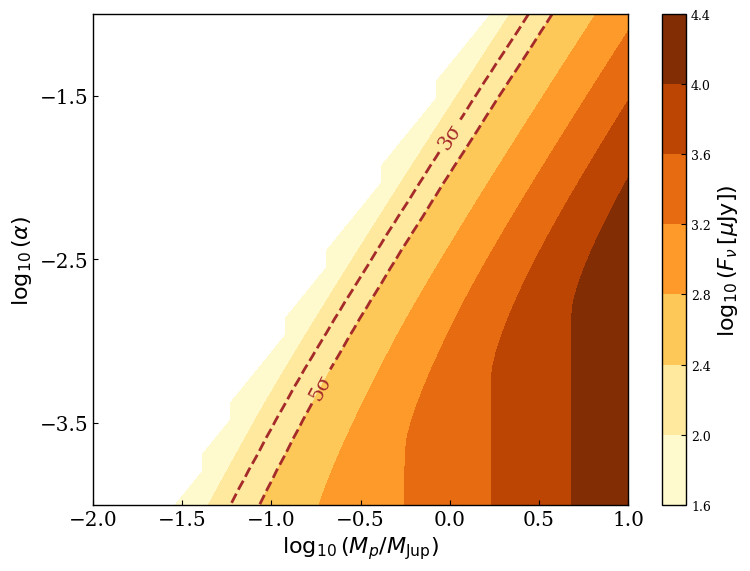

In [107]:
# Now plot Mp vs alpha 
# Use  Mp per Myear   

import numpy as np
from Zhu_model import compute_flux_map_zhu_MpAlpha, plot_zhu_Mp_alpha_flux
from Dictionaries import disk_arr  # adjust if needed


# choose a disk and parameters
disk_name = "CQ_Tau"
rp = 165          # au
Mdot = None # planet mass per Myr     # M_jup/M yr
lam_mm = 0.9      # mm
target_flux_arr = [50]  # μJy noise level ⇒ 3σ,5σ contours will scale from this

# 1) compute flux grid
Mp_grid, alpha_grid, Flux_map = compute_flux_map_zhu_MpAlpha(
    disk_arr[disk_name],
    Mdot=Mdot,
    rp=rp,
    lam_mm=lam_mm,
    verbose=False
)

# 2) plot (α on y-axis, Mp on x-axis)
plot_zhu_Mp_alpha_flux(
    Mp_grid, alpha_grid, Flux_map,
    disk_arr=disk_arr[disk_name],
    rp=rp,
    Mdot=Mdot,
    target_flux_arr=target_flux_arr
)

#### MAKE SURE ACCRETION RATE IN ANDREWS IS CONSISTENT WITH ZHU MODEL
### And Mpdot label 

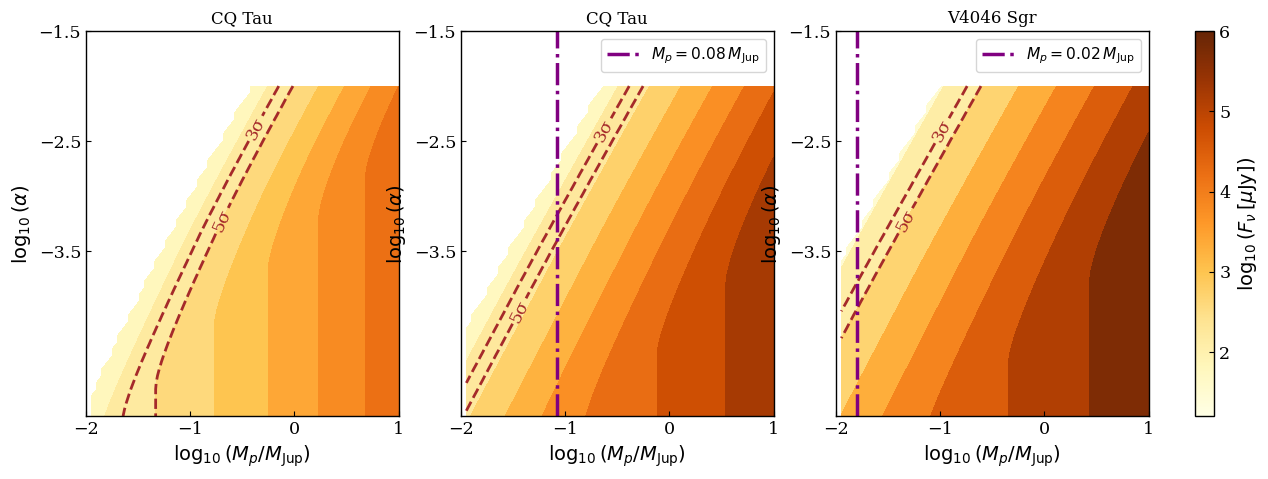

In [108]:
# ...existing code...
import numpy as np
import matplotlib.pyplot as plt
from Zhu_model import compute_flux_map_zhu_MpAlpha, plot_zhu_Mp_alpha_flux
from Dictionaries import disk_arr
from matplotlib import rcParams

# ============================================================
# GLOBAL VISUAL STYLE
# ============================================================
rcParams["font.size"] = 14
rcParams["font.family"] = "serif"
rcParams["axes.linewidth"] = 1.0
rcParams["xtick.direction"] = "in"
rcParams["ytick.direction"] = "in"

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=False, sharey=False)

# If axes is shape (1,3) in your environment, uncomment next line:
# axes = axes.flatten()

mappables = []  # <-- store one mappable per panel

for col, (disk_name, disk_radius) in enumerate(zip(disk_names, disk_radii)):
    ax = axes[col]

    Mp_grid, alpha_grid, Flux_map = compute_flux_map_zhu_MpAlpha(
        disk_arr[disk_name],
        Mdot=Mdot,
        rp=disk_radius,          # <-- per-panel rp
        lam_mm=lam_mm,
        Mp_min=-2, Mp_max=1, n_Mp=60,
        alpha_min=-5, alpha_max=-2, n_alpha=50,
        verbose=False
    )

    # IMPORTANT: capture the returned mappable
    im = plot_zhu_Mp_alpha_flux(
        Mp_grid, alpha_grid, Flux_map,
        disk_arr=disk_arr[disk_name],
        rp=disk_radius,          # <-- per-panel rp
        Mdot=Mdot,
        target_flux_arr=target_flux_arr,
        ax=ax
    )
    mappables.append(im)

    ax.set_title(disk_name.replace("_", " "))

# ---------- Shared colorbar ----------
# Make sure all panels share the same color scale
import matplotlib as mpl

# ---------- Shared colorbar (robust for contourf/pcolormesh/imshow) ----------
vmin = min(m.get_clim()[0] for m in mappables if m is not None and hasattr(m, "get_clim"))
vmax = max(m.get_clim()[1] for m in mappables if m is not None and hasattr(m, "get_clim"))

norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

# apply same normalization to all panels (works for images/meshes; contourf may still be level-based)
for m in mappables:
    if m is not None and hasattr(m, "set_norm"):
        m.set_norm(norm)

# create a standalone mappable just for the colorbar
cmap = mappables[0].cmap if (mappables and mappables[0] is not None and hasattr(mappables[0], "cmap")) else "viridis"
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=list(axes),
    fraction=0.046,
    pad=0.04
)
cbar.set_label(r"$\log_{10}(F_\nu\, [\mu{\rm Jy}])$", fontsize=rcParams["font.size"])
cbar.ax.tick_params(labelsize=rcParams["font.size"] * 0.9)

plt.show()
# ...existing code...

Low visocisty:  vertical bands, flux depends only on planet mass, not alpha.
High viscosity:  lowers the surface density (sigma proportional to Mdot/alpha) , need higher Mdot to obtain the same sigma , curve lower flux for same Mp because the disk is now 


WHen Mdot is high , optical thick, no alpha dependence  Low visocisty:  vertical bands, flux depends only on planet mass, not alpha.    .  Apart from when the viscosity is reli high lowers the surface density (sigma proportional to Mdot/alpha) , need higher Mdot to obtain the same sigma , curve lower flux for same Mp because the disk is now  

 But because Mdot is now Mp/Myr not a fixed value  . extra Mp dependence is introduced in the alpha plot adopting the way Andrews treat it.
 note that Mdot = Mp/myr woudl translate to a straigth line connecting to origin linearly log Mdot = Log Mp - 6. 

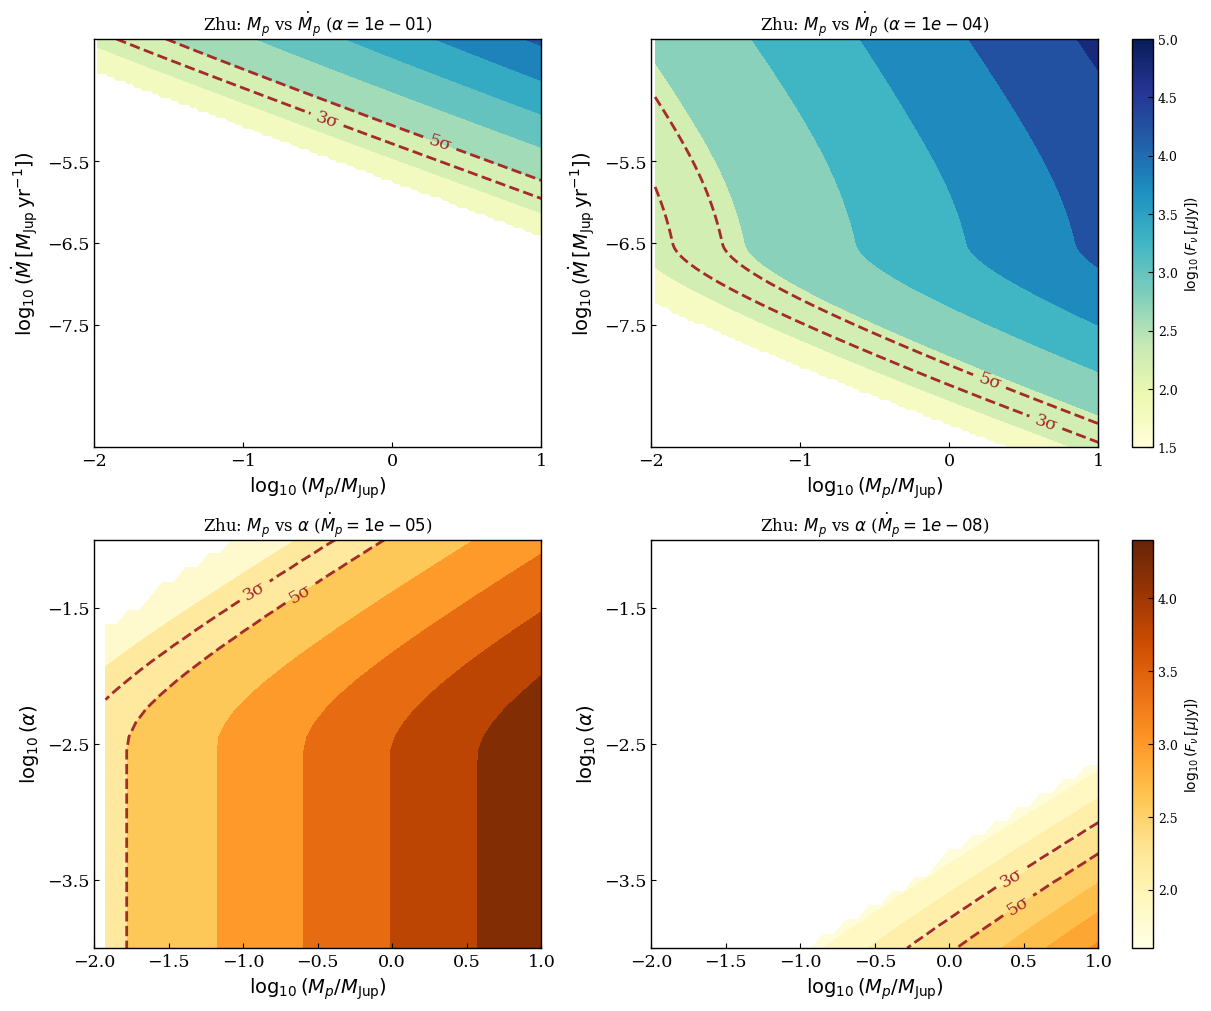

In [109]:
# Add a 2x2 plot: Zhu model
# Row 1: Mp vs Mdot (two alpha choices)
# Row 2: Mp vs alpha (two Mdot choices)
# + shared colorbar per row

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

import Zhu_model
from Dictionaries import disk_arr

# --------------------------
# Choose ONE system + rp etc.
# --------------------------
disk_name = "CQ_Tau"     # <-- set your target disk
rp = 165.37              # au
lam_mm = 0.9

# detection/target flux (μJy) used by Zhu plotting helpers for contours/lines
target_flux_arr = [50]   # <-- set to your measured peak flux (or sigma threshold)

# --------------------------
# Panel choices
# --------------------------
alpha_list_row1 = [1e-1, 1e-4]   # row 1 col0/col1
Mdot_list_row2  = [1e-5, 1e-8]   # row 2 col0/col1  (Mjup/yr)

# grids (increase N carefully; nested loops get slow)
Mp_grid   = np.logspace(-2, 1, 120)     # Mjup
Mdot_grid = np.logspace(-9, -4, 120)    # Mjup/yr

fig, ax = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)

# store mappables by row so we can row-normalize + add row colorbars
row_mappables = [[], []]

# ==========================
# Row 1: Mp vs Mdot (fixed alpha)
# ==========================
for col, alpha in enumerate(alpha_list_row1):
    Flux_vals = np.zeros((len(Mdot_grid), len(Mp_grid)))

    for i, Mdot in enumerate(Mdot_grid):
        for j, Mp in enumerate(Mp_grid):
            out = Zhu_model.calculate_disk_properties_zhu(
                M_star=disk_arr[disk_name][1],
                Mp=Mp,
                Mdot=Mdot,
                alpha=alpha,
                rp=rp,
                d_pc=disk_arr[disk_name][2],
                lam_mm=lam_mm,
                Lstar=disk_arr[disk_name][3],
            )
            Flux_vals[i, j] = out["F_nu_tot"]

    im = Zhu_model.plot_zhu_Mp_Mdot_flux(
        Mp_grid, Mdot_grid, Flux_vals,
        disk_arr=disk_arr[disk_name],
        rp=rp,
        alpha=alpha,
        target_flux_arr=target_flux_arr,
        ax=ax[0, col],
        plot_thick_thin=None,
        plot_Q = False
    )
    ax[0, col].set_title(rf"Zhu: $M_p$ vs $\dot{{M}}_p$ ($\alpha={alpha:.0e}$)")
    row_mappables[0].append(im)

# ==========================
# Row 2: Mp vs alpha (fixed Mdot)
# ==========================
for col, Mdot_fixed in enumerate(Mdot_list_row2):
    Mp_grid2, alpha_grid2, Flux_map = Zhu_model.compute_flux_map_zhu_MpAlpha(
        disk_arr[disk_name],
        Mdot=Mdot_fixed,
        rp=rp,
        verbose=False,
    )

    im = Zhu_model.plot_zhu_Mp_alpha_flux(
        Mp_grid2, alpha_grid2, Flux_map,
        disk_arr=disk_arr[disk_name],
        rp=rp,
        Mdot=Mdot_fixed,
        target_flux_arr=target_flux_arr,
        ax=ax[1, col],
    )
    ax[1, col].set_title(rf"Zhu: $M_p$ vs $\alpha$ ($\dot{{M}}_p={Mdot_fixed:.0e}$)")
    row_mappables[1].append(im)

# ==========================================================
# One shared colorbar per row (robust for contourf/imshow/etc.)
# ==========================================================
def _get_clim(m):
    if m is None:
        return None
    if hasattr(m, "get_clim"):
        return m.get_clim()
    # contourf returns QuadContourSet -> use first collection
    if hasattr(m, "collections") and m.collections:
        return m.collections[0].get_clim()
    return None

def _set_norm(m, norm):
    if m is None:
        return
    if hasattr(m, "set_norm"):
        m.set_norm(norm)
        return
    if hasattr(m, "collections") and m.collections:
        for c in m.collections:
            c.set_norm(norm)

def _get_cmap(m):
    if m is None:
        return mpl.cm.viridis
    if hasattr(m, "cmap"):
        return m.cmap
    if hasattr(m, "collections") and m.collections:
        return m.collections[0].cmap
    return mpl.cm.viridis

for r in (0, 1):
    maps = [m for m in row_mappables[r] if m is not None]
    clims = [_get_clim(m) for m in maps]
    clims = [c for c in clims if c is not None]
    if not clims:
        continue

    vmin = min(c[0] for c in clims)
    vmax = max(c[1] for c in clims)
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

    for m in maps:
        _set_norm(m, norm)

    sm = mpl.cm.ScalarMappable(norm=norm, cmap=_get_cmap(maps[0]))
    sm.set_array([])

    cb = fig.colorbar(
        sm,
        ax=[ax[r, 0], ax[r, 1]],   # <-- only this row
        fraction=0.046,
        pad=0.02
    )
    cb.set_label(r"$\log_{10}(F_\nu\,[\mu{\rm Jy}])$")

plt.show()

### Now for the kinks :)

In [ ]:
# load the kink info (disk name, radius :)) 
# Need to run get sigma at r?
# [disk_name, radius_au, sigma_flux]


In [ ]:
# just do row 3,4,5 at the moment

from matplotlib import rcParams
import matplotlib as mpl

# ============================================================
# GLOBAL VISUAL STYLE
# ============================================================
rcParams["font.size"] = 16
rcParams["font.family"] = "serif"
rcParams["axes.linewidth"] = 1.0
rcParams["xtick.direction"] = "in"
rcParams["ytick.direction"] = "in"


fig, axes = plt.subplots(
    5, 3, figsize=(15, 22.5),
    sharex=False, sharey=False,
    gridspec_kw={'height_ratios': [1, 1, 1, 1,1]}   # <-- force all rows equal height
)

# -------------------------------------------------------
# Save ONE mappable per row for the row-level colorbar
# -------------------------------------------------------
row_mappables = [None, None, [], [] ,[]]

for col, (disk_name, disk_radius, centroid, area , ylim) in enumerate(
        zip(disk_names, disk_radii, disk_centroid, disk_area, y_lim)):

    # =====================================================
    # ------------------------- ROW 1 ----------------------
    # =====================================================
    ax = axes[0, col]
    ax.set_aspect('equal', adjustable='box')

    img = fits.getdata(
        f'D:/CPD_MPIA/Median_SNR/SNR_FITS_Maps/{disk_name}_SNR_FullFOV_robust2.0.fits'
    )
    hdr = fits.getheader(
        f'D:/CPD_MPIA/Median_SNR/SNR_FITS_Maps/{disk_name}_SNR_FullFOV_robust2.0.fits'
    )

    im = plot_snr_zoom(ax, img, hdr, 1, centroid, area)

    if col == 2:     # save mappable from last column only
        row_mappables[0] = im


    # =====================================================
    # ------------------------- ROW 2 ----------------------
    # =====================================================
    ax = axes[1, col]
    ax.set_aspect('equal', adjustable='box')

    im = plot_snr_full_fov(ax, img, hdr, centroid)

    if col == 2:
        row_mappables[1] = im

    # =====================================================
    # ------------------------- ROW 3 ----------------------
    # =====================================================
    ax = axes[2, col]
    ax.set_aspect('auto')

    df = pd.read_csv(
        rf'D:\CPD_MPIA\CPD_Emission_Models\Andrews\{disk_name}_{disk_radius}_alpha0.001_5sigma.csv'
    )

    Mp_grid = df['Mp_grid'].unique()
    Rout_frac_grid = df['Rout_frac_grid'].unique()

    Flux_vals = df.pivot(
        index='Rout_frac_grid', columns='Mp_grid', values='Flux_vals'
    ).values

    M_cpd_chosen = df.pivot(
        index='Rout_frac_grid', columns='Mp_grid', values='Mcpd_vals'
    ).values

    im = Andrew_model.plot_flux_map(
         Mp_grid, Rout_frac_grid, Flux_vals, M_cpd_chosen,
         disk_arr=disk_arr[disk_name], ax=ax,
         rp=disk_radius, alpha=1e-3,
         x_min=-2, x_max=1,  
         y_min=ylim[0], y_max=ylim[1],
         min = -6, max = -2.5,
         res_au=disk_arr[disk_name][4] * disk_arr[disk_name][2],
         sigma_ujy=five_sigma_sources[col][3],
         det_sigma=five_sigma_sources[col][5],
    )

    # Save ALL 3 Andrew-model mappables for shared colorbar later
    #if row_mappables[2] is None:
    #    row_mappables[2] = []

    
    row_mappables[2].append(im)



    # =====================================================
    # ------------------------- ROW 4 ----------------------
    # =====================================================
    ax = axes[3, col]
    ax.set_aspect('auto')

    Mp_grid = np.logspace(-2, 1, 100)
    Mdot_grid = np.logspace(-8, -5, 100)

    Flux_vals = np.zeros((len(Mdot_grid), len(Mp_grid)))
    bmaj = disk_arr[disk_name][4] # arcsec

    for i, Mdot in enumerate(Mdot_grid):
        for j, Mp in enumerate(Mp_grid):

            RHill = five_sigma_sources[col][1] * (Mp / (3 * 1047.56 * disk_arr[disk_name][1]))**(1/3)
            Rout = 0.3 * RHill

            out = Zhu_model.calculate_disk_properties_zhu(
                M_star=disk_arr[disk_name][1],
                Mp=Mp,
                Mdot=Mdot,
                alpha=1e-3,
                rp=five_sigma_sources[col][1],
                d_pc=disk_arr[disk_name][2],
                lam_mm=0.9,
                Rout=Rout,
                Lstar=disk_arr[disk_name][3],
            )

            Flux_vals[i, j] = out["F_nu_tot"]

    im = Zhu_model.plot_zhu_Mp_Mdot_flux(
        Mp_grid, Mdot_grid, Flux_vals,
        disk_arr=disk_arr[disk_name],
        rp=disk_radius,
        alpha=1e-4,
        target_flux_arr=[five_sigma_sources[col][3]],
        ax=ax,
        beam_major_arcsec=bmaj,
        plot_thick_thin = True if col == 0 else False
    )

    row_mappables[3].append(im)


    # =====================================================
    # ------------------------- ROW 5 (NEW) ----------------
    # add Mp vs alpha Zhu map as requested
    # =====================================================
    ax = axes[4, col]
    ax.set_aspect('auto')

    # parameters for the new Mp-alpha panel (use example values; adapt if needed)

    rp_local = disk_radius
    Mdot = None       # M_jup/yr (adjust per-column if desired)

    target_flux_arr_local = [five_sigma_sources[col][3]]

    Mp_grid_alpha, alpha_grid, Flux_map = Zhu_model.compute_flux_map_zhu_MpAlpha(
            disk_arr[disk_name],
            Mdot=Mdot,
            rp=rp_local,
            lam_mm=0.9,
            verbose=False
        )

    im = Zhu_model.plot_zhu_Mp_alpha_flux(
            Mp_grid_alpha, alpha_grid, Flux_map,
            disk_arr=disk_arr[disk_name],
            rp=rp_local,
            Mdot=Mdot,
            target_flux_arr=target_flux_arr_local,
            beam_major_arcsec = disk_arr[disk_name][4],  # arcsec
            ax=ax
        )
    row_mappables[4].append(im)



# ===============================================================
# ---------------- ONE COLORBAR PER ROW -------------------------
# ===============================================================

for row in range(5):

    ax_last = axes[row, -1]
    pos = ax_last.get_position()

    # ===============================
    # ROW 0 & 1 
    # ===============================
    if row == 0 or row == 1:

        # Use SNR mappable from Row 0
        snr_mappable = row_mappables[0]

        # Position spans Row 0 + Row 1
        ax0 = axes[0, -1]
        ax1 = axes[1, -1]
        pos0 = ax0.get_position()
        pos1 = ax1.get_position()

        # Create shared vertical colorbar axis
        cax = fig.add_axes([
            pos.x1 + 0.01,
            pos.y0,
            0.015,
            pos.height
        ])

        cb = fig.colorbar(snr_mappable, cax=cax)
        cb.set_label("SNR", fontsize=rcParams["font.size"])

        # Remove left ticks (NO MORE 0–1 scale)
        cb.ax.tick_params(left=False, labelleft=False)

    # ===============================
    # ROW 2 → shared Andrews model bar
    # ===============================
    elif row == 2:

        # Compute shared vmin/vmax
        mapps = row_mappables[2]


        vmin, vmax = -6, -2.5
        norm = plt.Normalize(vmin=vmin, vmax=vmax)

        for m in mapps:
            m.set_norm(norm)

        # Create colorbar axis ONLY here
        cax = fig.add_axes([
            pos.x1 + 0.01,
            pos.y0,
            0.015,
            pos.height
        ])

        cb = fig.colorbar(mapps[0], cax=cax)
        cb.set_label(r"$\log_{10}(M_{\rm CPD}/M_{\rm Jup})$", fontsize=rcParams["font.size"])

    # ===============================
    # ROW 3 → normal Zhu colorbar
    # ===============================
    elif row == 3 or row ==4:
        if row == 3:
            mapps = row_mappables[3]  # list of 3 mappables
        else :
            mapps = row_mappables[4] 

        vmin = min(m.get_clim()[0] for m in mapps if m is not None and hasattr(m, "get_clim"))
        vmax = max(m.get_clim()[1] for m in mapps if m is not None and hasattr(m, "get_clim"))

        norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

        for m in mapps:
            if m is not None and hasattr(m, "set_norm"):
                m.set_norm(norm)

        cmap = mapps[0].cmap if (mapps and mapps[0] is not None and hasattr(mapps[0], "cmap")) else "viridis"
        sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
        sm.set_array([])

        cax = fig.add_axes([pos.x1 + 0.01, pos.y0, 0.015, pos.height])
        cb = fig.colorbar(sm, cax=cax)
        cb.set_label(r"$\log_{10}(F_\nu\, [\mu{\rm Jy}])$", fontsize=rcParams["font.size"])
        cb.ax.tick_params(labelsize=rcParams["font.size"] * 0.9)

   


#          LEFT Y-LABELS FOR EACH ROW (PUBLICATION STYLE)
# ===============================================================

row_side_labels = [
    "SNR (Zoom)", "SNR (Full FOV)",
    "Mp vs Rout",
    "Mp vs Mdot",
    "Mp vs α"
]

for row in range(5):
    axes[row,0].annotate(
            row_side_labels[row],
            xy=(0, 0.5), xycoords='axes fraction',
            xytext=(-60, 0), textcoords='offset points',
            ha='right', va='center',
            rotation='vertical',
            fontsize=14, fontweight='bold'
        )

# ===============================================================
#        ADD OVERALL COLUMN LABELS AT TOP
# ===============================================================
column_titles = ["CQ Tau (r=165 AU)", "CQ Tau (r=932 AU)", "V4046 Sgr (r=838 AU)"]
for col in range(3):
    axes[0, col].set_title(column_titles[col], fontsize=14, pad=10, fontweight='bold')

# ===============================================================
#     ADJUST SPACING FOR LABELS AND COLORBARS
# ===============================================================
plt.subplots_adjust(
    left=0.12,    # restore left margin
    hspace=0.35,
    wspace=0.30
)


plt.show()


### Chapter 5: Inspecting the Imageloop Residuals

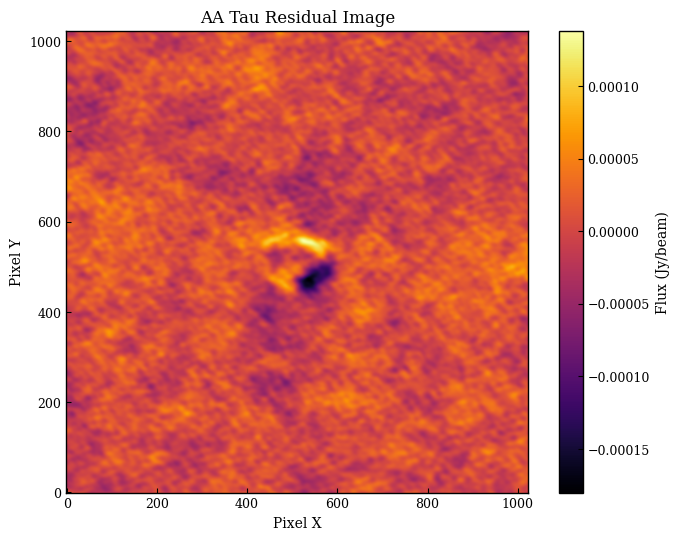

In [18]:
# Plot and inspect a resid fit

# Plot a FITS image in Python
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np

fits_path = r'D:\CPD_MPIA\Injection_Recovery_trial_fBf\J1852_robust2_0_gap0\resid_images\J1852_gap0.F34uJy_0000.resid.fits'
img = fits.getdata(fits_path)
img = np.squeeze(img)  # Remove extra dimensions if present

plt.figure(figsize=(8, 6))
plt.imshow(img, origin='lower', cmap='inferno')
plt.colorbar(label='Flux (Jy/beam)')
plt.title('AA Tau Residual Image')
plt.xlabel('Pixel X')
plt.ylabel('Pixel Y')
plt.show()
